In [4]:
import pandas as pd

df = pd.read_csv("beauty_reviews.csv")

df.head()

,product/productId,product/title,product/price,review/userId,review/profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,B00064C0IU,Oscar Eau de Toilette for Women by Oscar de La...,24.19,A1FWT811DSZLC8,Heidi M,0/0,3.0,1360368000,doesn't last,very light scent that doesn't last very long. ...
1,B00064C0IU,Oscar Eau de Toilette for Women by Oscar de La...,24.19,A1THE6V6O8ROD4,"Donna Mpaulin ""PURPLE RAVEN""",0/0,5.0,1358467200,Smells divine.,"This is my second bottle of sheer freesia, I j..."
2,B00064C0IU,Oscar Eau de Toilette for Women by Oscar de La...,24.19,A176IQ7MVD3N6T,M. Avila,0/0,1.0,1357084800,Very disappointed!,This perfume is just AWFUL! Smells nothing lik...
3,B00064C0IU,Oscar Eau de Toilette for Women by Oscar de La...,24.19,A34BDX4JVMG23Y,Kim M. Colt,0/0,5.0,1326240000,Nice gift,This was a gift for my sister. It wowed her. S...
4,B000K5JBZU,Optimum Care Anti-Breakage Therapy Moisture Re...,5.99,A3UWJXJI7S3T05,PloveJ,1/1,5.0,1351987200,TRULY MADE A DIFFERENCE!,I have been using this product for a couple ye...


In [5]:
print(df.columns)

Index(['product/productId', 'product/title', 'product/price', 'review/userId',
       'review/profileName', 'review/helpfulness', 'review/score',
       'review/time', 'review/summary', 'review/text'],
      dtype='object')


In [6]:
df.rename(columns={
    'review/text': 'review',
    'review/score': 'review_score',
    'product/productId': 'product_Id',
    'product/price' : 'product_price',
    'review/userId': 'review_userId',
    'review/profileName': 'review_profile_Name',
    'review/helpfulness': 'review_helpfulness',
     'review/time': 'review_time',
     'product/title': 'product_title',
    'review/summary': 'review_summary'
}, inplace=True)

In [7]:
print(df.columns)

Index(['product_Id', 'product_title', 'product_price', 'review_userId',
       'review_profile_Name', 'review_helpfulness', 'review_score',
       'review_time', 'review_summary', 'review'],
      dtype='object')


In [8]:
print(df.shape)

(252056, 10)


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252056 entries, 0 to 252055
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   product_Id           252056 non-null  object 
 1   product_title        251997 non-null  object 
 2   product_price        252056 non-null  object 
 3   review_userId        252056 non-null  object 
 4   review_profile_Name  252040 non-null  object 
 5   review_helpfulness   252056 non-null  object 
 6   review_score         252056 non-null  float64
 7   review_time          252056 non-null  int64  
 8   review_summary       252054 non-null  object 
 9   review               252056 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 19.2+ MB
None


In [10]:
df['product_price'] = pd.to_numeric(df['product_price'], errors='coerce')

df['review_score'] = df['review_score'].astype(float)

df['review_time'] = pd.to_datetime(df['review_time'], unit='s')

text_columns = [
    'product_title',
    'review_profile_Name',
    'review_summary',
    'review'
]

for col in text_columns:
    df[col] = df[col].astype(str)

print(df.dtypes)

product_Id                     object
product_title                  object
product_price                 float64
review_userId                  object
review_profile_Name            object
review_helpfulness             object
review_score                  float64
review_time            datetime64[ns]
review_summary                 object
review                         object
dtype: object


In [11]:
print(df.isnull().sum())

product_Id                 0
product_title              0
product_price          38788
review_userId              0
review_profile_Name        0
review_helpfulness         0
review_score               0
review_time                0
review_summary             0
review                     0
dtype: int64


In [12]:
median_price = df['product_price'].median()

df['product_price'] = df['product_price'].fillna(median_price)

print(df['product_price'].isnull().sum())

0


In [13]:
print(df.duplicated().sum())

68


In [14]:
print("Duplicate rows before removing:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removing:", df.duplicated().sum())

Duplicate rows before removing: 68
Duplicate rows after removing: 0


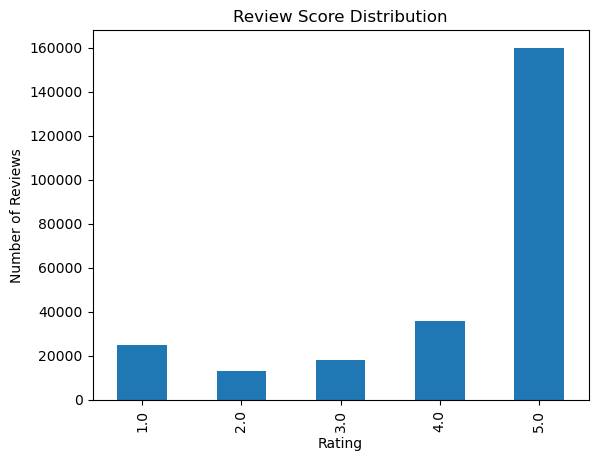

In [15]:
import matplotlib.pyplot as plt

df['review_score'].value_counts().sort_index().plot(kind='bar')

plt.title('Review Score Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

“Most customers provided 5-star ratings, indicating high overall customer satisfaction and positive product perception.”

## Review Score Distribution Analysis

The bar chart illustrates the distribution of customer ratings from 1 to 5 stars. The majority of customers provided 5-star ratings, indicating a highly positive overall customer experience and strong satisfaction with the products.

### Key Insights
- 5-star ratings dominate the dataset.
- Lower ratings are comparatively fewer.
- Most customers appear satisfied with product quality and performance.



In [16]:
def rating_to_sentiment(rating):

    if rating >= 4:
        return 'Positive'

    elif rating == 3:
        return 'Neutral'

    else:
        return 'Negative'

df['Sentiment'] = df['review_score'].apply(rating_to_sentiment)

print(df[['review_score', 'Sentiment']].head())

   review_score Sentiment
0           3.0   Neutral
1           5.0  Positive
2           1.0  Negative
3           5.0  Positive
4           5.0  Positive


In [17]:
df['Sentiment'].value_counts()

Sentiment
Positive    195884
Negative     37929
Neutral      18175
Name: count, dtype: int64

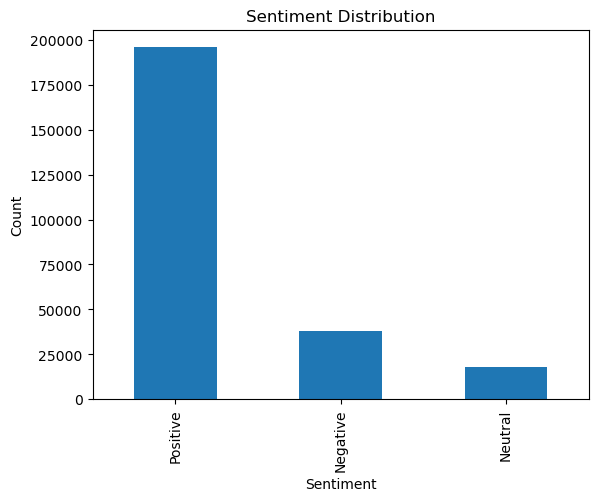

In [18]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()

## Sentiment Distribution Analysis

The sentiment distribution graph shows that the majority of customer reviews are positive, while a smaller portion of reviews are negative or neutral. This indicates overall customer satisfaction and favorable product experiences.

### Key Insights
- Positive sentiment dominates the dataset.
- Negative and neutral reviews are comparatively lower.
- Customers generally express positive opinions toward the products.



In [19]:
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_review(text):

    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

df['Cleaned_Review'] = df['review'].apply(clean_review)

print(df[['review', 'Cleaned_Review']].head())

[nltk_data] Downloading package stopwords to C:\Users\DIPESH
[nltk_data]     DUBEY\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                              review  \
0  very light scent that doesn't last very long. ...   
1  This is my second bottle of sheer freesia, I j...   
2  This perfume is just AWFUL! Smells nothing lik...   
3  This was a gift for my sister. It wowed her. S...   
4  I have been using this product for a couple ye...   

                                      Cleaned_Review  
0  light scent doesnt last long pretty bottle hop...  
1  second bottle sheer freesia love fragrance lig...  
2  perfume awful smells nothing like freesiathe g...  
3  gift sister wowed always worn freesia typicall...  
4  using product couple years started using hair ...  


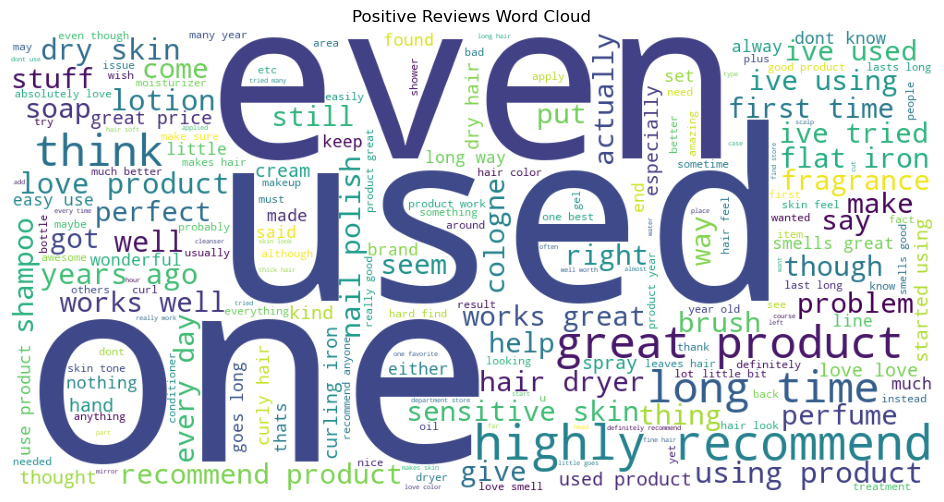

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = ' '.join(
    df[df['Sentiment'] == 'Positive']['Cleaned_Review']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Positive Reviews Word Cloud')

plt.show()

## Positive Reviews Word Cloud Analysis

The positive reviews word cloud highlights the most frequently used words in satisfied customer feedback. Words such as “great”, “recommend”, “love”, “works”, and “perfect” appear prominently, reflecting strong customer satisfaction and positive product experiences.

### Key Insights
- Customers frequently expressed satisfaction with product quality and performance.
- Positive reviews emphasized effectiveness, usability, and overall experience.
- Recommendation-related words indicate strong customer trust and loyalty.



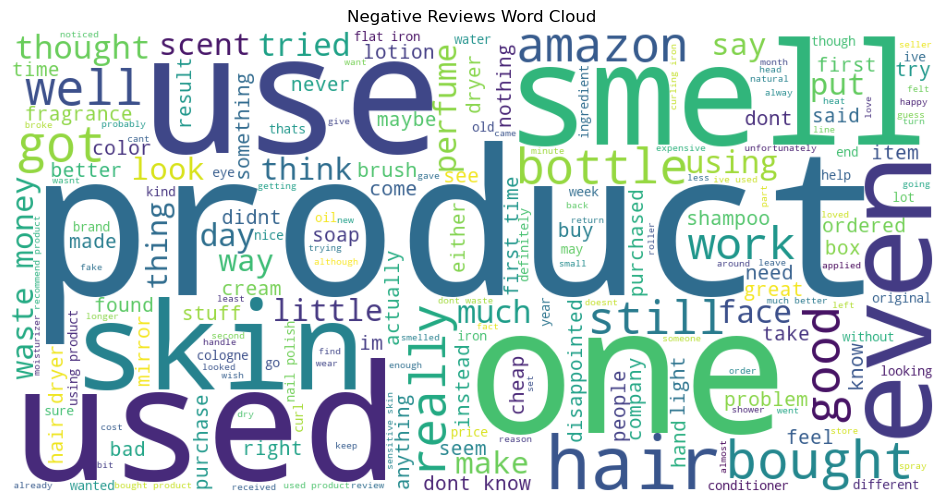

In [21]:
negative_text = ' '.join(
    df[df['Sentiment'] == 'Negative']['Cleaned_Review']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Negative Reviews Word Cloud')

plt.show()

## Negative Reviews Word Cloud Analysis

The negative reviews word cloud highlights the most commonly used words in dissatisfied customer feedback. Terms such as “smell”, “problem”, “skin”, “bottle”, and “money” appear prominently, indicating common customer concerns related to product quality, packaging, fragrance, and overall effectiveness.

### Key Insights
- Customers frequently reported issues related to smell and product performance.
- Packaging and bottle-related complaints were also observed.
- Negative feedback helps identify areas requiring product improvement and quality enhancement.

In [22]:
from collections import Counter

all_words = ' '.join(df['Cleaned_Review']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

print(common_words)

[('hair', 149779), ('product', 127987), ('like', 84766), ('use', 80825), ('skin', 77704), ('one', 69947), ('great', 66820), ('love', 60105), ('used', 53879), ('would', 53556), ('good', 51103), ('really', 49677), ('get', 49196), ('using', 47230), ('time', 45954), ('color', 44188), ('well', 39895), ('dont', 39705), ('ive', 38816), ('years', 37140)]


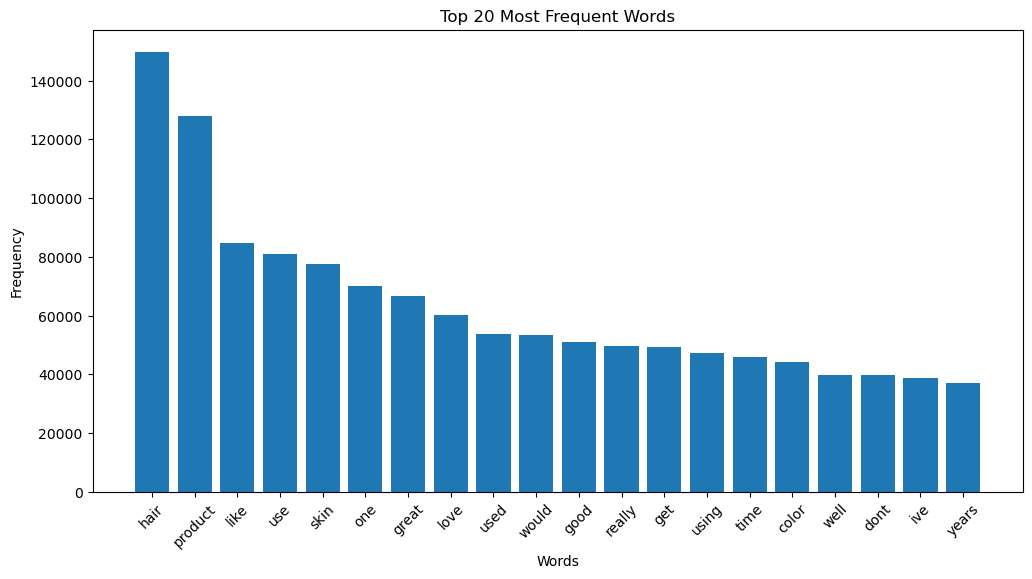

In [23]:
words = [word[0] for word in common_words]

counts = [word[1] for word in common_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title('Top 20 Most Frequent Words')

plt.xlabel('Words')

plt.ylabel('Frequency')

plt.show()

## Top 20 Most Frequent Words Analysis

The bar chart represents the most frequently occurring words in customer reviews after text preprocessing. Words such as “hair”, “product”, “great”, “love”, and “good” appear most frequently, indicating that customers commonly discuss product usage, quality, and satisfaction.

### Key Insights
- Positive words like “great” and “love” occur frequently, reflecting overall customer satisfaction.
- Product-related terms dominate the reviews, showing strong customer engagement with product features and performance.
- Frequent usage of descriptive words helps identify important customer preferences and concerns.

### Business Impact
Analyzing frequent words helps businesses understand customer interests, improve product quality, and design more effective marketing strategies.

In [24]:
emotion_keywords = {

    'Happy': [
        'love', 'great', 'best',
        'amazing', 'perfect',
        'excellent', 'happy'
    ],

    'Sad': [
        'bad', 'disappointed',
        'poor', 'waste'
    ],

    'Angry': [
        'worst', 'hate',
        'awful', 'terrible',
        'problem'
    ],

    'Fear': [
        'scared', 'fear',
        'worry'
    ],

    'Surprise': [
        'wow', 'surprised',
        'unexpected'
    ]
}

In [25]:
def detect_emotion(text):

    text = str(text).lower()

    for emotion, keywords in emotion_keywords.items():

        for word in keywords:

            if word in text:
                return emotion

    return 'Neutral'

In [26]:
df['Emotion'] = df['Cleaned_Review'].apply(detect_emotion)

print(df[['Cleaned_Review', 'Emotion']].head())

                                      Cleaned_Review   Emotion
0  light scent doesnt last long pretty bottle hop...   Neutral
1  second bottle sheer freesia love fragrance lig...     Happy
2  perfume awful smells nothing like freesiathe g...     Angry
3  gift sister wowed always worn freesia typicall...  Surprise
4  using product couple years started using hair ...     Happy


In [27]:
df['Emotion'].value_counts()

Emotion
Happy       140375
Neutral      90600
Sad          11556
Angry         7500
Surprise      1443
Fear           514
Name: count, dtype: int64

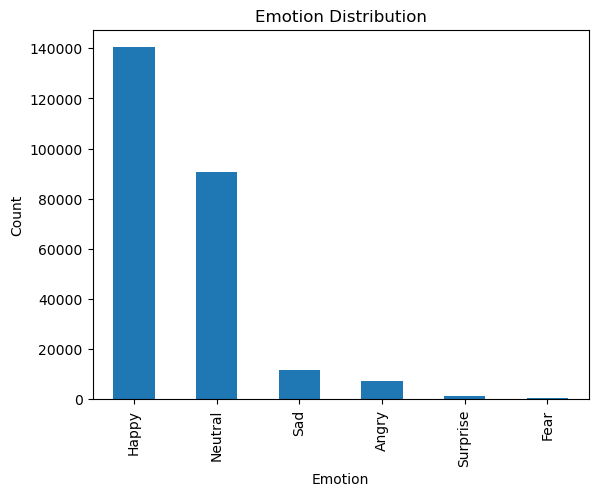

In [28]:
df['Emotion'].value_counts().plot(kind='bar')

plt.title('Emotion Distribution')

plt.xlabel('Emotion')

plt.ylabel('Count')

plt.show()

## Emotion Distribution Analysis

The emotion distribution graph shows that the majority of customer reviews express happy and positive emotions, while only a smaller portion reflects sadness, anger, fear, or surprise.

### Key Insight
Most customers appear satisfied with the products, indicating a generally positive customer experience and strong product acceptance.

In [29]:
reviews_per_year = df.groupby(
    df['review_time'].dt.year
).size()

print(reviews_per_year)

review_time
1997        1
1998       11
1999      345
2000     1611
2001      131
2002      276
2003      494
2004     2232
2005     4746
2006     7025
2007    18651
2008    21922
2009    22625
2010    27967
2011    44540
2012    71965
2013    27446
dtype: int64


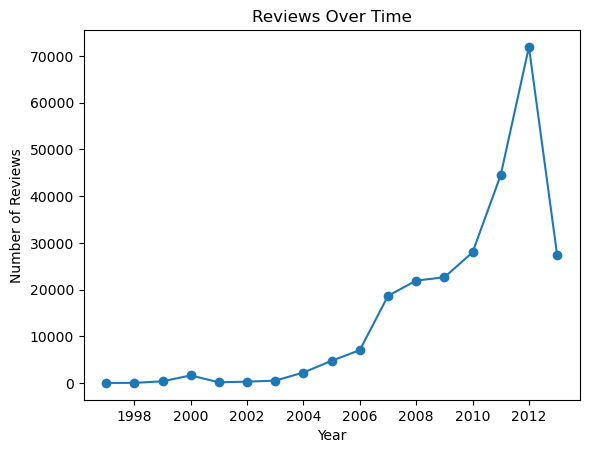

In [30]:
reviews_per_year.plot(kind='line', marker='o')

plt.title('Reviews Over Time')

plt.xlabel('Year')

plt.ylabel('Number of Reviews')

plt.show()

## Reviews Over Time Analysis

The line graph illustrates the growth of customer reviews over different years. Review activity remained relatively low during the early years but increased significantly after 2006, reaching its peak around 2012.

### Key Insight
The increasing number of reviews over time indicates growing customer engagement, product popularity, and expansion of online purchasing activity.

In [31]:
sentiment_percent = (
    df['Sentiment'].value_counts(normalize=True) * 100
)

print(sentiment_percent)

Sentiment
Positive    77.735448
Negative    15.051907
Neutral      7.212645
Name: proportion, dtype: float64


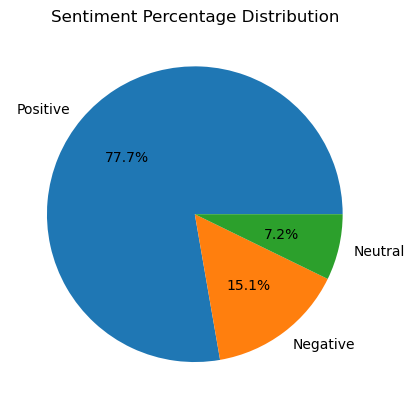

In [32]:
sentiment_percent.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Sentiment Percentage Distribution')

plt.ylabel('')

plt.show()

## Sentiment Percentage Distribution

The pie chart represents the overall sentiment distribution of customer reviews. The majority of reviews are positive, indicating high customer satisfaction and favorable product experience.

### Key Insights
- Positive Reviews: 77.7%
- Negative Reviews: 15.1%
- Neutral Reviews: 7.2%


In [33]:
print("Average Rating:", df['review_score'].mean())

Average Rating: 4.162690286839056


In [34]:
df['Review_Length'] = df['review'].apply(len)

print(df['Review_Length'].describe())

count    251988.000000
mean        382.829242
std         386.916222
min           7.000000
25%         156.000000
50%         262.000000
75%         465.000000
max       19324.000000
Name: Review_Length, dtype: float64


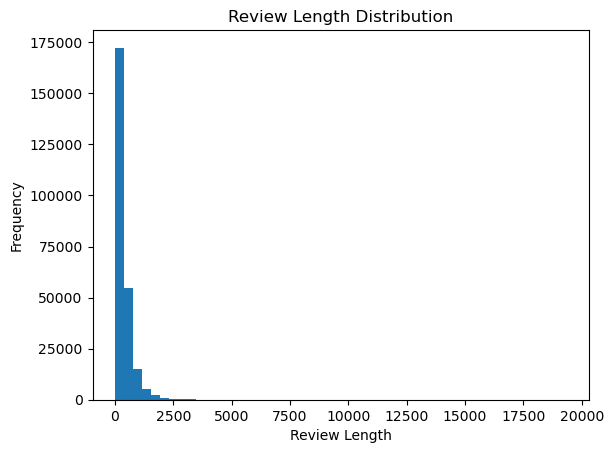

In [35]:
df['Review_Length'].plot(kind='hist', bins=50)

plt.title('Review Length Distribution')

plt.xlabel('Review Length')

plt.show()

## Review Length Distribution

The histogram shows the distribution of customer review lengths. Most reviews are relatively short, while a smaller number of reviews are highly detailed and lengthy.

### Key Insight
The dataset is positively skewed, indicating that customers generally provide concise feedback, with only a few users writing extensive reviews.

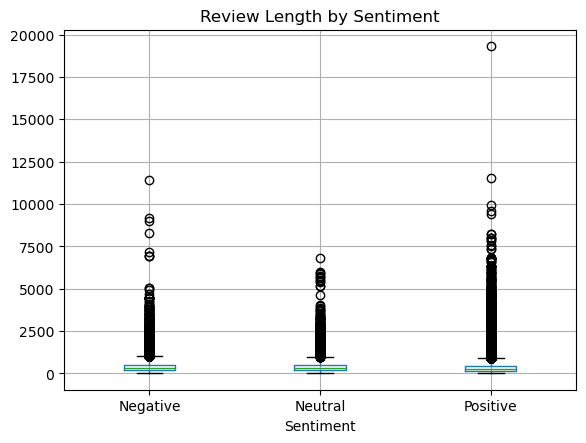

In [36]:
df.boxplot(column='Review_Length', by='Sentiment')

plt.title('Review Length by Sentiment')

plt.suptitle('')

plt.show()

## Review Length by Sentiment

The boxplot shows the distribution of review lengths across different sentiment categories. Positive reviews generally contain longer and more detailed feedback compared to negative and neutral reviews.

### Key Insight
Customers with positive experiences tend to write more descriptive reviews, while negative and neutral reviews are comparatively shorter.

In [37]:
top_positive = df[df['Sentiment'] == 'Positive'][
    'product_title'
].value_counts().head(10)

print(top_positive)

product_title
China Glaze Nail Lacquer with Hardeners                                    4422
Essie Spring '06 Collection                                                2085
Dr. Bronner - Castile Soap                                                 1851
Farouk CHI 1 Inch Ceramic Flat Hairstyling Iron                            1595
Mavala Stop - Helps Cure Nail Biting and Thumb Sucking, 0.3-Fluid Ounce    1081
Hot Tools Professional Curling Iron with Multi-Heat Control                1019
Zoya Nail Polish                                                            939
Aquolina Pink Sugar                                                         678
Auric Blends Perfume Oil                                                    620
Bare Escentuals BareMinerals                                                573
Name: count, dtype: int64


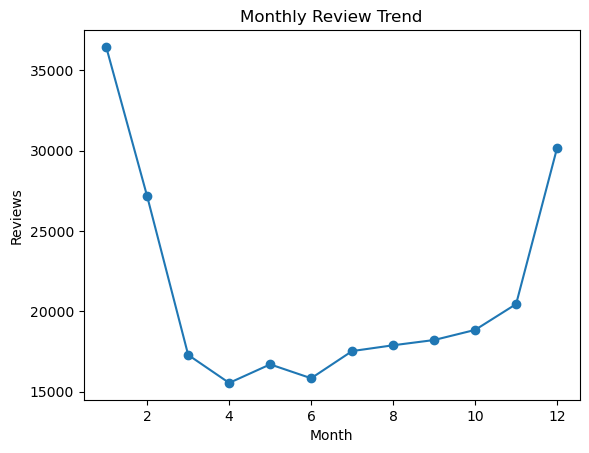

In [38]:
monthly_reviews = df.groupby(
    df['review_time'].dt.month
).size()

monthly_reviews.plot(kind='line', marker='o')

plt.title('Monthly Review Trend')

plt.xlabel('Month')

plt.ylabel('Reviews')

plt.show()

## Monthly Review Trend Analysis

The monthly review trend visualization shows the distribution of customer reviews across different months of the year. The graph indicates that customer review activity was highest during January and December, while comparatively fewer reviews were recorded during the middle months of the year.

This trend suggests increased customer engagement and purchasing activity during the beginning and end of the year, possibly due to seasonal sales, festive shopping periods, or promotional campaigns.

### Key Insights
- January recorded the highest number of reviews.
- Review activity declined during March to June.
- A gradual increase in reviews was observed from July onwards.
- December showed another significant rise in customer activity.



# Final Project Summary

This project focused on performing Sentiment Analysis and Emotion Detection on Amazon product review data using Natural Language Processing (NLP) techniques. The dataset was cleaned and preprocessed by handling missing values, removing duplicate records, converting datatypes, and cleaning review text for analysis.

Exploratory Data Analysis (EDA) was performed to understand customer behavior, rating patterns, review trends, and product popularity. Multiple visualizations such as sentiment distribution graphs, review score analysis, word clouds, emotion distribution charts, review length analysis, and time trend analysis were created to gain meaningful insights from the data.

The sentiment analysis results showed that the majority of customer reviews were positive, indicating high customer satisfaction and strong product acceptance. Emotion analysis further revealed that happy emotions dominated customer feedback, while only a small percentage of reviews expressed sadness, anger, fear, or surprise.

Word cloud analysis highlighted commonly used positive and negative terms, helping identify customer preferences, complaints, and product-related concerns. Time trend analysis demonstrated increasing customer engagement and review activity over the years.

Overall, this project successfully demonstrated how NLP and sentiment analysis techniques can help businesses understand customer opinions, improve products, enhance marketing strategies, and make data-driven business decisions.